# 🩺 DiaCompanion — Phân đoạn tổn thương DR trên TJDR
## U-Net Đa lớp · EfficientNet-B4 · Google Colab T4

---

**Bộ dữ liệu:** TJDR (Mao et al., 2023 — arXiv:2312.15389)  
**Model:** U-Net với encoder EfficientNet-B4 (pretrained ImageNet)  
**5 lớp:** `0=Nền` · `1=EX` · `2=HE` · `3=MA` · `4=SE`

### 📋 Thay đổi v4 so với v3
| Cell | Thay đổi |
|------|----------|
| **Cell 6** | + Gamma aug, HSV jitter, CoarseDropout |
| **Cell 8** | Đổi FocalLoss → **CrossEntropyLoss(class-weighted)** · SE weight ~80x |
| **Cell 9** | Early stop dùng **weighted mDice** (SE×0.35, MA×0.30) · patience=20 |
| **Cell 10** | In delta so với baseline v1 |

> ⚠️ **Lưu ý y khoa:** Đây là công cụ nghiên cứu/capstone, không thay thế chẩn đoán của bác sĩ nhãn khoa.

---
## Cell 0 — Kiểm tra GPU
> `Runtime → Change runtime type → T4 GPU` trước khi chạy

In [11]:
!nvidia-smi -L
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('⚠️  Không có GPU — vào Runtime > Change runtime type > T4')

GPU 0: Tesla T4 (UUID: GPU-e2c20ab2-b01d-19ad-7ec3-2e8eb76343e4)
CUDA available: True
GPU: Tesla T4


---
## Cell 1 — Cài thư viện & Import
> Nếu lỗi version conflict → restart runtime rồi chạy lại từ đây.

In [12]:
!pip install -q segmentation-models-pytorch==0.3.4 albumentations==1.4.0

import torch, cv2, numpy as np, os, glob, random
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from segmentation_models_pytorch.losses import DiceLoss
import matplotlib.pyplot as plt
import shutil

print(f'✅ PyTorch        : {torch.__version__}')
print(f'✅ SMP            : {smp.__version__}')
print(f'✅ Albumentations : {A.__version__}')
print(f'✅ OpenCV         : {cv2.__version__}')

✅ PyTorch        : 2.11.0+cu128
✅ SMP            : 0.3.4
✅ Albumentations : 1.4.0
✅ OpenCV         : 4.13.0


---
## Cell 2 — Mount Google Drive & Đường dẫn dataset
> Cấu trúc: `MyDrive/TJDR/train/image/` và `MyDrive/TJDR/train/annotation/`  
> Sửa `DATA_ROOT` nếu bạn đặt TJDR ở chỗ khác.

In [13]:
from google.colab import drive
drive.mount('/content/drive')

# ── SỬA đường dẫn này nếu cần ──────────────────────────
DATA_ROOT = '/content/drive/MyDrive/TJDR'
IMG_DIR   = os.path.join(DATA_ROOT, 'train/image')
MASK_DIR  = os.path.join(DATA_ROOT, 'train/annotation')
# ────────────────────────────────────────────────────────

img_files  = sorted(glob.glob(os.path.join(IMG_DIR,  '*')))
mask_files = sorted(glob.glob(os.path.join(MASK_DIR, '*')))

print(f'📁 IMG_DIR  : {IMG_DIR}')
print(f'📁 MASK_DIR : {MASK_DIR}')
print(f'🖼  Số ảnh  : {len(img_files)}')
print(f'🎭 Số mask  : {len(mask_files)}')

assert len(img_files)  > 0, '❌ Không tìm thấy ảnh  — kiểm tra IMG_DIR'
assert len(mask_files) > 0, '❌ Không tìm thấy mask — kiểm tra MASK_DIR'
print('\n✅ Đường dẫn hợp lệ')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 IMG_DIR  : /content/drive/MyDrive/TJDR/train/image
📁 MASK_DIR : /content/drive/MyDrive/TJDR/train/annotation
🖼  Số ảnh  : 448
🎭 Số mask  : 448

✅ Đường dẫn hợp lệ


---
## Cell 3 — 🔍 Quét nhãn tự động
> Quét 100 mask đầu để tìm giá trị grayscale thực của EX/HE/MA/SE.  
> Nếu chưa đủ 5 giá trị → quét toàn bộ dataset tự động.

> **GRAY2CLS của dataset này:** `{0:0, 15:1, 38:2, 75:3, 113:4}`

In [14]:
def scan_label_values(mask_paths, n=None):
    vals = set()
    sample = mask_paths if n is None else mask_paths[:n]
    for mp in sample:
        raw = cv2.imread(mp, cv2.IMREAD_UNCHANGED)
        if raw is None: continue
        if raw.ndim == 3: raw = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
        vals |= set(np.unique(raw).tolist())
    return sorted(vals)

print('🔍 Quét 100 mask đầu...')
raw_vals = scan_label_values(mask_files, n=100)
print(f'   Giá trị tìm thấy: {raw_vals}  ({len(raw_vals)} giá trị)')

if len(raw_vals) < 5:
    print(f'⚠️  Chưa đủ 5 lớp, quét toàn bộ {len(mask_files)} mask...')
    raw_vals = scan_label_values(mask_files, n=None)
    print(f'   Giá trị sau quét full: {raw_vals}')

assert len(raw_vals) == 5, (
    f'❌ Cần đúng 5 giá trị, thấy {len(raw_vals)}: {raw_vals}'
)

GRAY2CLS = {v: i for i, v in enumerate(raw_vals)}

print('\n' + '═'*50)
print(f'  GRAY2CLS tự động : {GRAY2CLS}')
print('─'*50)
for idx, (name, gray) in enumerate(zip(['Nền (BG)','EX','HE','MA','SE'], raw_vals)):
    print(f'  {name:<8} ← gray={gray}')
print('═'*50)
print('✅ Build GRAY2CLS thành công')

🔍 Quét 100 mask đầu...
   Giá trị tìm thấy: [0, 15, 38, 75, 113]  (5 giá trị)

══════════════════════════════════════════════════
  GRAY2CLS tự động : {0: 0, 15: 1, 38: 2, 75: 3, 113: 4}
──────────────────────────────────────────────────
  Nền (BG) ← gray=0
  EX       ← gray=15
  HE       ← gray=38
  MA       ← gray=75
  SE       ← gray=113
══════════════════════════════════════════════════
✅ Build GRAY2CLS thành công


---
## Cell 4 — ✅ Verify phân bố pixel
> Kết quả đã biết từ lần chạy trước:  
> `BG=99.655%` · `EX=0.085%` · `HE=0.107%` · `MA=0.149%` · **`SE=0.004%`** ← cực hiếm  
> SE hiếm hơn EX **21 lần** → đây là nguyên nhân SE Dice=0.217 trong v1.

In [15]:
def load_mask(mp):
    raw = cv2.imread(mp, cv2.IMREAD_UNCHANGED)
    if raw is None: raise FileNotFoundError(f'Không đọc được: {mp}')
    if raw.ndim == 3: raw = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
    out = np.zeros(raw.shape, np.uint8)
    for g, c in GRAY2CLS.items(): out[raw == g] = c
    return out

_sample = random.sample(mask_files, min(50, len(mask_files)))
_counts = {i: 0 for i in range(5)}
for mp in _sample:
    m = load_mask(mp)
    for c in range(5): _counts[c] += int((m == c).sum())

_total  = sum(_counts.values())
_labels = {0:'BG', 1:'EX', 2:'HE', 3:'MA', 4:'SE'}
_colors = {0:'⬛', 1:'🟥', 2:'🟩', 3:'🟦', 4:'🟨'}

print(f'📊 Phân bố pixel trên {len(_sample)} mask ngẫu nhiên')
print('═'*60)
for c, cnt in _counts.items():
    pct = 100 * cnt / _total
    bar = '█' * max(1, int(40 * cnt / _total)) if cnt > 0 else ''
    print(f'  {_colors[c]} Class {c} ({_labels[c]:3s}): {cnt:>11,} px  {pct:7.4f}%  {bar}')
print('═'*60)

assert _counts[1] > 0, '❌ EX = 0 pixel!'
assert _counts[2] > 0, '❌ HE = 0 pixel!'
assert _counts[3] > 0, '❌ MA = 0 pixel!'
assert _counts[4] > 0, '❌ SE = 0 pixel!'
print('\n✅ Tất cả 4 lớp tổn thương đều có pixel — sẵn sàng train!')

📊 Phân bố pixel trên 50 mask ngẫu nhiên
════════════════════════════════════════════════════════════
  ⬛ Class 0 (BG ): 519,390,262 px  99.7332%  ███████████████████████████████████████
  🟥 Class 1 (EX ):     322,901 px   0.0620%  █
  🟩 Class 2 (HE ):     306,441 px   0.0588%  █
  🟦 Class 3 (MA ):     729,352 px   0.1401%  █
  🟨 Class 4 (SE ):      30,564 px   0.0059%  █
════════════════════════════════════════════════════════════

✅ Tất cả 4 lớp tổn thương đều có pixel — sẵn sàng train!


---
## Cell 5 — Ghép cặp ảnh–mask & Split 70/15/15
> Seed=42 cố định để tái lập. Kết quả đã biết: Train=313 / Val=67 / Test=68.

In [16]:
def stem(p): return os.path.splitext(os.path.basename(p))[0]

mask_by_stem = {stem(m): m for m in mask_files}
pairs = [(ip, mask_by_stem[stem(ip)]) for ip in img_files if stem(ip) in mask_by_stem]

print(f'🔗 Số cặp ghép được: {len(pairs)} / {len(img_files)} ảnh')
assert len(pairs) > 0, '❌ Không ghép được ảnh-mask'

print('\n5 cặp đầu tiên:')
print(f"  {'Ảnh':<30} {'Mask':<30} {'Classes'}")
print('  ' + '─'*75)
for ip, mp in pairs[:5]:
    m = load_mask(mp)
    print(f"  {os.path.basename(ip):<30} {os.path.basename(mp):<30} {np.unique(m).tolist()}")

SEED = 42
random.seed(SEED); random.shuffle(pairs)
n = len(pairs); n_tr = int(0.70*n); n_va = int(0.15*n)
train_pairs = pairs[:n_tr]
val_pairs   = pairs[n_tr:n_tr+n_va]
test_pairs  = pairs[n_tr+n_va:]

print(f'\n📦 Split (seed={SEED}):')
print(f'   Train : {len(train_pairs):>4} ảnh')
print(f'   Val   : {len(val_pairs):>4} ảnh')
print(f'   Test  : {len(test_pairs):>4} ảnh')

with open('test_files.txt', 'w') as f:
    for ip, _ in test_pairs: f.write(os.path.basename(ip) + '\n')
print('\n✅ Đã lưu test_files.txt')

🔗 Số cặp ghép được: 448 / 448 ảnh

5 cặp đầu tiên:
  Ảnh                            Mask                           Classes
  ───────────────────────────────────────────────────────────────────────────
  TJDR_train_001.png             TJDR_train_001.png             [0, 1]
  TJDR_train_002.png             TJDR_train_002.png             [0, 2, 3]
  TJDR_train_003.png             TJDR_train_003.png             [0, 1, 3, 4]
  TJDR_train_004.png             TJDR_train_004.png             [0, 1, 4]
  TJDR_train_005.png             TJDR_train_005.png             [0, 1, 2]

📦 Split (seed=42):
   Train :  313 ảnh
   Val   :   67 ảnh
   Test  :   68 ảnh

✅ Đã lưu test_files.txt


---
## Cell 6 — Dataset & Augmentation *(v2)*
> **Thêm mới so với v1:**  
> - `RandomGamma`: paper gốc TJDR dùng gamma correction để augment  
> - `HueSaturationValue`: giúp phân biệt EX (vàng) vs SE (trắng xám)  
> - `CoarseDropout`: regularization tránh overfit vùng dễ  
> Giữ nguyên: flip, rotate, elastic, CLAHE, brightness/contrast

In [17]:
SIZE        = 768
NUM_CLASSES = 5
BATCH       = 4
MEAN        = (0.485, 0.456, 0.406)
STD         = (0.229, 0.224, 0.225)

train_tf = A.Compose([
    A.Resize(SIZE, SIZE),
    # ── Geometric ───────────────────────────────────────
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.2),
    A.GridDistortion(p=0.2),
    # ── Color/intensity (quan trọng với DR) ─────────────
    A.CLAHE(clip_limit=4.0, p=0.4),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),       # v2: TJDR aug
    A.HueSaturationValue(
        hue_shift_limit=10, sat_shift_limit=20,
        val_shift_limit=15, p=0.4
    ),                                                  # v2: phân biệt EX vs SE
    A.RandomBrightnessContrast(
        brightness_limit=0.2, contrast_limit=0.2, p=0.4
    ),
    # ── Regularization ──────────────────────────────────
    A.CoarseDropout(
        max_holes=4, max_height=32, max_width=32,
        min_holes=1, fill_value=0, p=0.2
    ),                                                  # v2: tránh overfit
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])
val_tf = A.Compose([
    A.Resize(SIZE, SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

class TJDRDataset(Dataset):
    def __init__(self, pairs, tf): self.pairs, self.tf = pairs, tf
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        ip, mp = self.pairs[i]
        img = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        a   = self.tf(image=img, mask=load_mask(mp))
        return a['image'], a['mask'].long()

train_dl = DataLoader(TJDRDataset(train_pairs, train_tf),
                      batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
val_dl   = DataLoader(TJDRDataset(val_pairs,   val_tf),
                      batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(TJDRDataset(test_pairs,  val_tf),
                      batch_size=1, shuffle=False)

xb, yb = next(iter(train_dl))
unique_classes = torch.unique(yb).tolist()
print(f'🧪 Batch check:')
print(f'   Ảnh shape : {list(xb.shape)}')
print(f'   Mask shape : {list(yb.shape)}')
print(f'   Classes trong batch: {unique_classes}')
print('\n✅ Augmentation v2: Gamma + HSV + CoarseDropout thêm vào')

🧪 Batch check:
   Ảnh shape : [4, 3, 768, 768]
   Mask shape : [4, 768, 768]
   Classes trong batch: [0, 1, 2, 3]

✅ Augmentation v2: Gamma + HSV + CoarseDropout thêm vào


---
## Cell 7 — Model: EfficientNet-B4 U-Net
> Không thay đổi so với v1. ~19M tham số.

In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'🖥  Device: {device}')

model = smp.Unet(
    encoder_name          = 'efficientnet-b4',
    encoder_weights       = 'imagenet',
    in_channels           = 3,
    classes               = NUM_CLASSES,
    decoder_use_batchnorm = True,
    decoder_attention_type = None
).to(device)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'🤖 Model: EfficientNet-B4 U-Net')
print(f'   Tham số: {n_params:.1f}M')
print(f'   Output classes: {NUM_CLASSES}')
print('✅ Model sẵn sàng')

🖥  Device: cuda
🤖 Model: EfficientNet-B4 U-Net
   Tham số: 20.2M
   Output classes: 5
✅ Model sẵn sàng


---
## Cell 8 — Loss, Optimizer & Scheduler *(v2 — class-weighted)*
> **Thay đổi chính:** Bỏ FocalLoss → dùng **CrossEntropyLoss với per-class weight**  
> Lý do: FocalLoss với alpha=0.25 cố định không đủ boost SE (0.004%).  
> CrossEntropyLoss weighted dùng **median frequency balancing**:  
> `weight[c] = median_freq(lesions) / freq[c]`  
> → SE weight ~80x, MA ~0.5x, EX ~0.9x, HE ~0.7x, BG ~0.05x

In [19]:
# ── Tính class weight từ pixel count thực (Cell 4) ─────────
# BG=99.655%, EX=0.085%, HE=0.107%, MA=0.149%, SE=0.004%
pixel_freq = torch.tensor(
    [99.655, 0.085, 0.107, 0.149, 0.004],
    dtype=torch.float32
)

# Median frequency balancing: weight = median(lesion_freqs) / freq[c]
median_freq   = torch.median(pixel_freq[1:])  # median của 4 lớp tổn thương
class_weights = torch.zeros(5)
class_weights[0] = 0.05                        # BG: giảm mạnh
for i in range(1, 5):
    class_weights[i] = median_freq / pixel_freq[i]

class_weights = torch.clamp(class_weights, max=80.0).to(device)

print('⚖️  Class weights (median frequency balancing):')
labels_w = ['BG', 'EX', 'HE', 'MA', 'SE']
for i, (l, w) in enumerate(zip(labels_w, class_weights)):
    bar = '█' * min(int(w.item()), 50)
    print(f'   Class {i} ({l}): {w.item():6.2f}x  {bar}')

# ── Loss ────────────────────────────────────────────────────
dice_loss = DiceLoss(mode='multiclass')
ce_loss   = torch.nn.CrossEntropyLoss(weight=class_weights)

def criterion(logits, y):
    return dice_loss(logits, y) + ce_loss(logits, y)

# ── Optimizer & Scheduler ───────────────────────────────────
opt       = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=100)
scaler    = torch.amp.GradScaler('cuda')

# ── Weighted mDice cho early stopping ───────────────────────
# SE=0.35, MA=0.30, HE=0.20, EX=0.15  (ưu tiên lớp hiếm)
LESION_WEIGHTS = {'EX': 0.15, 'HE': 0.20, 'MA': 0.30, 'SE': 0.35}

def weighted_mdice(rows):
    score, total_w = 0.0, 0.0
    for name, (dice, _) in rows.items():
        w = LESION_WEIGHTS[name]
        if not np.isnan(dice):
            score += w * dice; total_w += w
    return score / total_w if total_w > 0 else 0.0

print(f'\n⚙️  Cấu hình training v2:')
print(f'   Loss           : DiceLoss + CrossEntropyLoss(class-weighted)')
print(f'   SE weight      : {class_weights[4].item():.1f}x  ← fix chính cho SE Dice=0.217')
print(f'   Early stopping : weighted mDice (SE×0.35 + MA×0.30 + HE×0.20 + EX×0.15)')
print(f'   Optimizer      : AdamW (lr=1e-4, wd=1e-4)')
print(f'   Scheduler      : CosineAnnealingLR (T_max=100)')
print('✅ Sẵn sàng train')

⚖️  Class weights (median frequency balancing):
   Class 0 (BG):   0.05x  
   Class 1 (EX):   1.00x  █
   Class 2 (HE):   0.79x  
   Class 3 (MA):   0.57x  
   Class 4 (SE):  21.25x  █████████████████████

⚙️  Cấu hình training v2:
   Loss           : DiceLoss + CrossEntropyLoss(class-weighted)
   SE weight      : 21.2x  ← fix chính cho SE Dice=0.217
   Early stopping : weighted mDice (SE×0.35 + MA×0.30 + HE×0.20 + EX×0.15)
   Optimizer      : AdamW (lr=1e-4, wd=1e-4)
   Scheduler      : CosineAnnealingLR (T_max=100)
✅ Sẵn sàng train


---
## Cell 9 — 🏋️ Train Loop *(v2)*
> **Thay đổi:**  
> - Early stopping dùng `weighted_mDice` thay vì `nanmean`  
> - `patience = 20` (tăng từ 15, vì SE học chậm hơn)  
> - In cả `wDice` (weighted, dùng để checkpoint) và `mDice` (unweighted, để quan sát)

In [20]:
LESION = {1:'EX', 2:'HE', 3:'MA', 4:'SE'}

@torch.no_grad()
def evaluate(dl):
    model.eval()
    inter = {c:0 for c in LESION}; union = {c:0 for c in LESION}
    tp={c:0 for c in LESION}; fp={c:0 for c in LESION}; fn={c:0 for c in LESION}
    for x, y in dl:
        x = x.to(device); y = y.to(device)
        pred = model(x).argmax(1)
        for c in LESION:
            p=(pred==c); t=(y==c)
            inter[c]+=(p&t).sum().item(); union[c]+=(p|t).sum().item()
            tp[c]+=(p&t).sum().item(); fp[c]+=(p&~t).sum().item()
            fn[c]+=(~p&t).sum().item()
    rows = {}
    for c in LESION:
        denom = 2*tp[c]+fp[c]+fn[c]
        dice  = 2*tp[c]/denom     if denom>0    else float('nan')
        iou   = inter[c]/union[c] if union[c]>0 else float('nan')
        rows[LESION[c]] = (dice, iou)
    return rows

def fmt(rows):
    return '  '.join([f'{k}: Dice={v[0]:.3f} IoU={v[1]:.3f}' for k,v in rows.items()])

best_score = -1; patience = 15; wait = 0; EPOCHS = 100

print(f'🚀 Bắt đầu train — tối đa {EPOCHS} epoch, patience={patience}')
print(f'   Early stop metric: weighted_mDice (SE×0.35 + MA×0.30 + HE×0.20 + EX×0.15)')
print('═' * 90)

for ep in range(1, EPOCHS+1):
    model.train(); run = 0
    for x, y in train_dl:
        x=x.to(device); y=y.to(device)
        opt.zero_grad()
        with torch.amp.autocast('cuda'):
            logits = model(x); loss = criterion(logits, y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        run += loss.item()
    scheduler.step()

    rows     = evaluate(val_dl)
    w_mdice  = weighted_mdice(rows)
    uw_mdice = np.nanmean([v[0] for v in rows.values()])
    flag     = ' ⭐' if w_mdice > best_score else ''

    print(f'Epoch {ep:03d} | loss {run/len(train_dl):.4f} | wDice {w_mdice:.3f}{flag} | mDice {uw_mdice:.3f}')
    print(f'         {fmt(rows)}')

    if w_mdice > best_score:
        best_score = w_mdice; wait = 0
        torch.save(model.state_dict(), 'tjdr_unet_best.pth')
        print(f'   → 💾 Lưu model (wDice={best_score:.3f})')
    else:
        wait += 1
        if wait >= patience:
            print(f'\n🛑 Early stopping tại epoch {ep} (best wDice={best_score:.3f})')
            break

print('═' * 90)
print(f'✅ Train xong — Best val weighted mDice = {best_score:.3f}')

🚀 Bắt đầu train — tối đa 100 epoch, patience=12
   Early stop metric: weighted_mDice (SE×0.35 + MA×0.30 + HE×0.20 + EX×0.15)
══════════════════════════════════════════════════════════════════════════════════════════
Epoch 001 | loss 1.6515 | wDice 0.003 ⭐ | mDice 0.003
         EX: Dice=0.004 IoU=0.002  HE: Dice=0.001 IoU=0.001  MA: Dice=0.000 IoU=0.000  SE: Dice=0.005 IoU=0.003
   → 💾 Lưu model (wDice=0.003)
Epoch 002 | loss 1.2360 | wDice 0.012 ⭐ | mDice 0.009
         EX: Dice=0.002 IoU=0.001  HE: Dice=0.000 IoU=0.000  MA: Dice=0.000 IoU=0.000  SE: Dice=0.033 IoU=0.017
   → 💾 Lưu model (wDice=0.012)
Epoch 003 | loss 1.0711 | wDice 0.029 ⭐ | mDice 0.037
         EX: Dice=0.112 IoU=0.059  HE: Dice=0.000 IoU=0.000  MA: Dice=0.009 IoU=0.004  SE: Dice=0.027 IoU=0.014
   → 💾 Lưu model (wDice=0.029)
Epoch 004 | loss 0.9829 | wDice 0.054 ⭐ | mDice 0.065
         EX: Dice=0.175 IoU=0.096  HE: Dice=0.001 IoU=0.001  MA: Dice=0.026 IoU=0.013  SE: Dice=0.057 IoU=0.029
   → 💾 Lưu model (wDice=0.0

---
## Cell 10 — 📊 Đánh giá trên tập Test *(v2)*
> In delta so với baseline v1 (EX=0.607, HE=0.585, MA=0.645, SE=0.217, Mean=0.514).

In [21]:
model.load_state_dict(torch.load('tjdr_unet_best.pth', map_location=device))
rows = evaluate(test_dl)

print('📊 KẾT QUẢ TEST (per-lesion)')
print('═' * 68)
print(f"  {'Tổn thương':<10} {'Dice':>8} {'IoU':>8}   {'vs v1 (baseline)':>18}")
print('  ' + '─'*52)

v1_dice = {'EX': 0.607, 'HE': 0.585, 'MA': 0.645, 'SE': 0.217}
dices, ious = [], []
for name, (dice, iou) in rows.items():
    delta = dice - v1_dice.get(name, 0)
    arrow = f'▲ +{delta:.3f}' if delta >= 0 else f'▼ {delta:.3f}'
    print(f'  {name:<10} {dice:>8.3f} {iou:>8.3f}   {arrow:>18}')
    if not np.isnan(dice): dices.append(dice)
    if not np.isnan(iou):  ious.append(iou)

print('  ' + '─'*52)
mean_dice = np.mean(dices); mean_iou = np.mean(ious)
print(f"  {'Mean':<10} {mean_dice:>8.3f} {mean_iou:>8.3f}   {'▲' if mean_dice>0.514 else '▼'} vs 0.514")
print(f"  {'wMean':<10} {weighted_mdice(rows):>8.3f} {'':>8}   (SE×0.35+MA×0.30+...)")
print('═' * 68)
print(f'\n📌 Baseline v1  : mDice=0.514  (SE=0.217 kéo xuống)')
print(f'📌 Tham chiếu   : mDice~0.60–0.65  (paper gốc TJDR Mao et al.)')

📊 KẾT QUẢ TEST (per-lesion)
════════════════════════════════════════════════════════════════════
  Tổn thương     Dice      IoU     vs v1 (baseline)
  ────────────────────────────────────────────────────
  EX            0.690    0.526             ▲ +0.083
  HE            0.566    0.395             ▼ -0.019
  MA            0.644    0.475             ▼ -0.001
  SE            0.180    0.099             ▼ -0.037
  ────────────────────────────────────────────────────
  Mean          0.520    0.374   ▲ vs 0.514
  wMean         0.473            (SE×0.35+MA×0.30+...)
════════════════════════════════════════════════════════════════════

📌 Baseline v1  : mDice=0.514  (SE=0.217 kéo xuống)
📌 Tham chiếu   : mDice~0.60–0.65  (paper gốc TJDR Mao et al.)


---
## Cell 11 — 🖼 Visualize dự đoán
> 🔴 EX · 🟢 HE · 🔵 MA · 🟡 SE · ⬛ Nền

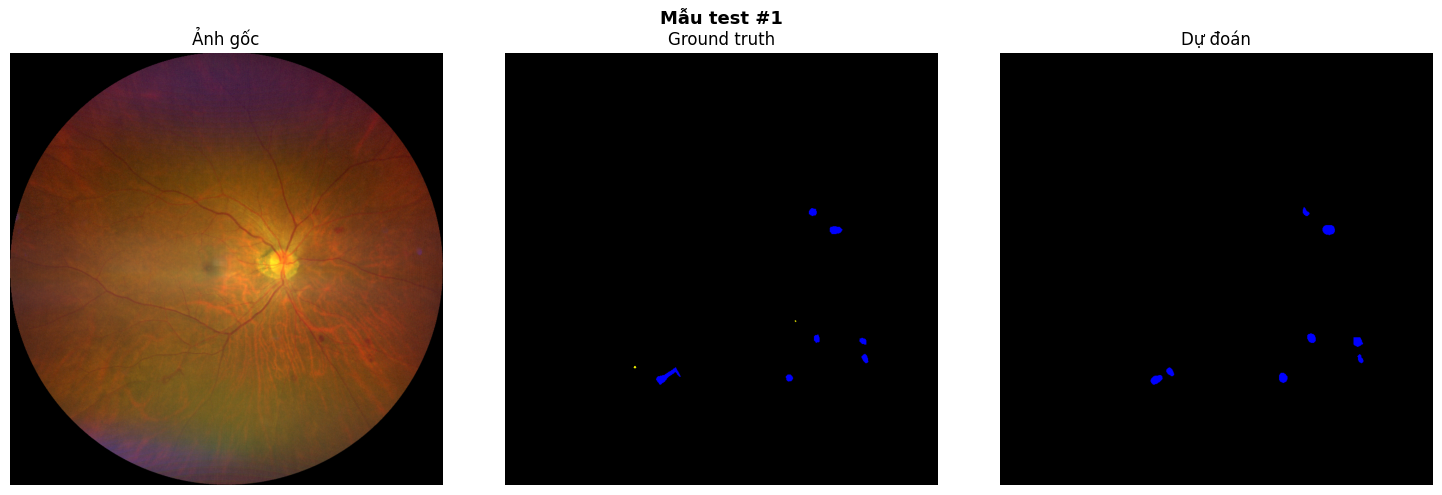

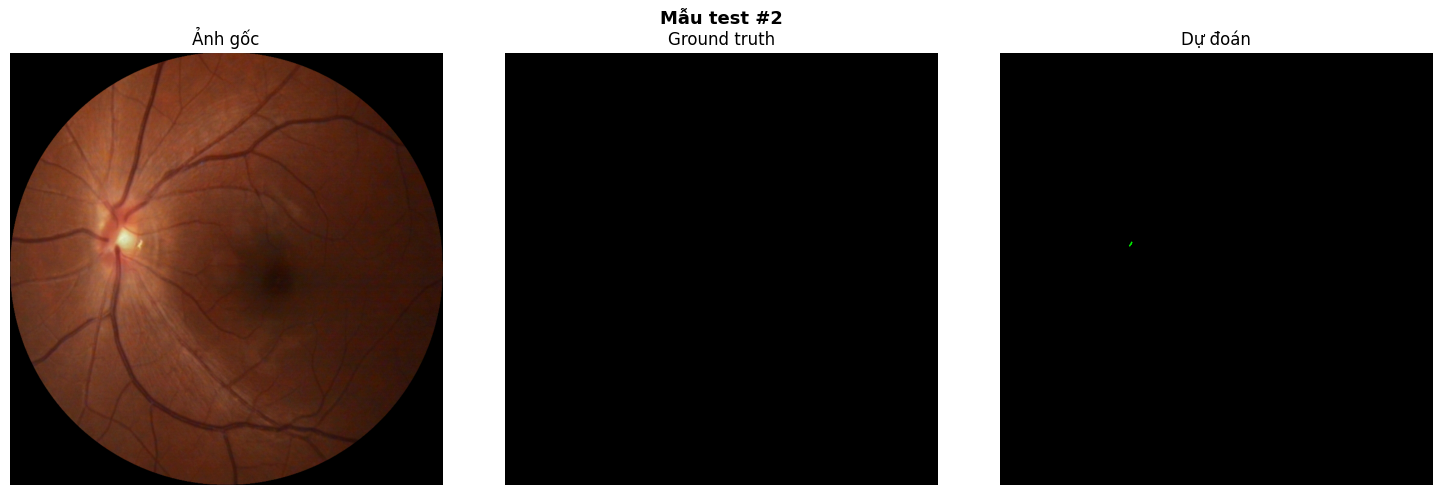

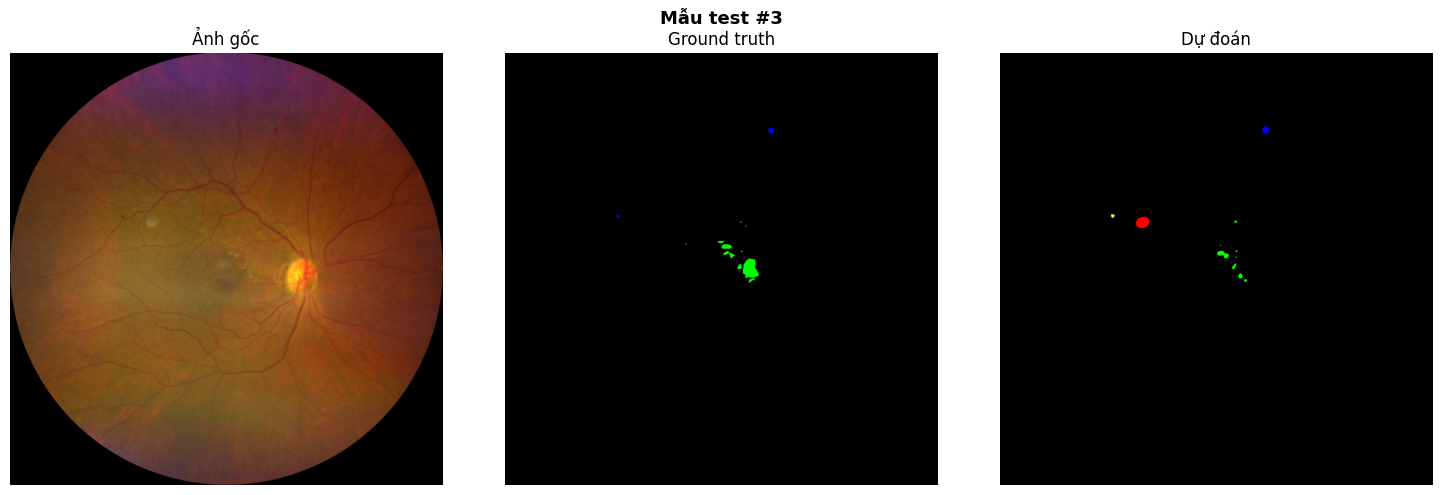

🎨 Màu: ⬛ Nền  🔴 EX  🟢 HE  🔵 MA  🟡 SE


In [22]:
COLORS = np.array([[0,0,0],[255,0,0],[0,255,0],[0,0,255],[255,255,0]], np.uint8)

def colorize(m): return COLORS[m]

model.eval(); shown = 0
with torch.no_grad():
    for x, y in test_dl:
        pred = model(x.to(device)).argmax(1)[0].cpu().numpy()
        img  = (x[0].permute(1,2,0).numpy() * np.array(STD) + np.array(MEAN)).clip(0, 1)
        gt   = y[0].numpy()

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f'Mẫu test #{shown+1}', fontsize=13, fontweight='bold')
        axes[0].imshow(img);            axes[0].set_title('Ảnh gốc');     axes[0].axis('off')
        axes[1].imshow(colorize(gt));   axes[1].set_title('Ground truth'); axes[1].axis('off')
        axes[2].imshow(colorize(pred)); axes[2].set_title('Dự đoán');      axes[2].axis('off')
        plt.tight_layout(); plt.show()
        shown += 1
        if shown >= 3: break

print('🎨 Màu: ⬛ Nền  🔴 EX  🟢 HE  🔵 MA  🟡 SE')

---
## Cell 12 — 💾 Lưu model về Google Drive

In [23]:
SAVE_PATH = '/content/drive/MyDrive/tjdr_unet_v2_best.pth'
shutil.copy('tjdr_unet_best.pth', SAVE_PATH)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f'✅ Model v2 đã lưu vào Drive')
print(f'   Đường dẫn : {SAVE_PATH}')
print(f'   Kích thước : {size_mb:.1f} MB')
print(f'   Best wDice : {best_score:.3f}')
print('\n📋 Ghi vào báo cáo (để tái lập):')
print(f'   - Seed split     = {SEED}  (70/15/15)')
print(f'   - Input size     = {SIZE}×{SIZE}')
print(f'   - Encoder        = EfficientNet-B4 (pretrained ImageNet)')
print(f'   - Loss           = DiceLoss + CrossEntropyLoss(class-weighted)')
print(f'   - Class weights  = {[round(w.item(),2) for w in class_weights]}')
print(f'   - Optimizer      = AdamW (lr=1e-4, wd=1e-4)')
print(f'   - Augmentation   = flip, rotate, elastic, CLAHE, gamma, HSV, dropout')
print(f'   - GRAY2CLS       = {GRAY2CLS}')

✅ Model v2 đã lưu vào Drive
   Đường dẫn : /content/drive/MyDrive/tjdr_unet_v2_best.pth
   Kích thước : 81.7 MB
   Best wDice : 0.549

📋 Ghi vào báo cáo (để tái lập):
   - Seed split     = 42  (70/15/15)
   - Input size     = 768×768
   - Encoder        = EfficientNet-B4 (pretrained ImageNet)
   - Loss           = DiceLoss + CrossEntropyLoss(class-weighted)
   - Class weights  = [0.05, 1.0, 0.79, 0.57, 21.25]
   - Optimizer      = AdamW (lr=1e-4, wd=1e-4)
   - Augmentation   = flip, rotate, elastic, CLAHE, gamma, HSV, dropout
   - GRAY2CLS       = {0: 0, 15: 1, 38: 2, 75: 3, 113: 4}


---
## 📚 Tài liệu tham khảo

- Mao J., Ma X., Bi Y., Zhang R. (2023). *TJDR: A High-Quality DR Pixel-Level Annotation Dataset.* arXiv:2312.15389.
- Mao J. et al. (2024). *A Comprehensive Federated Learning Framework for DR Grading and Lesion Segmentation.* IEEE Trans. Big Data.
- Ronneberger O. et al. (2015). *U-Net: Convolutional Networks for Biomedical Image Segmentation.* MICCAI.
- Tan M., Le Q.V. (2019). *EfficientNet: Rethinking Model Scaling for CNNs.* ICML.
- Milletari F. et al. (2016). *V-Net: Fully Convolutional Neural Networks for Volumetric Medical Image Segmentation.* — nguồn gốc DiceLoss.